# Quickstart: Twisted Bilayer Graphene in 5 Minutes

In this tutorial, you will simulate **Twisted Bilayer Graphene (TBG)** from scratch. MoirePy abstracts the geometric complexity of commensurate lattice construction, allowing you to go from a twist angle to a Hamiltonian in seconds.

## 1. Minimal Installation

```bash
pip install moirepy
```

## 2. Construct the Moire Lattice

We use the built-in `HexagonalLayer` (Graphene) to construct the bilayer. While this example focuses on graphene, MoirePy includes several other built-in geometries:

* **`SquareLayer`**
* **`TriangularLayer`**
* **`KagomeLayer`**
* **`Rhombus60Layer`**

You can also define your own entirely unique geometries; see [Defining Custom Layers](prepare_layers.md) for more.

twist angle = 0.1646 rad (9.4300 deg)
74 cells in upper lattice
74 cells in lower lattice


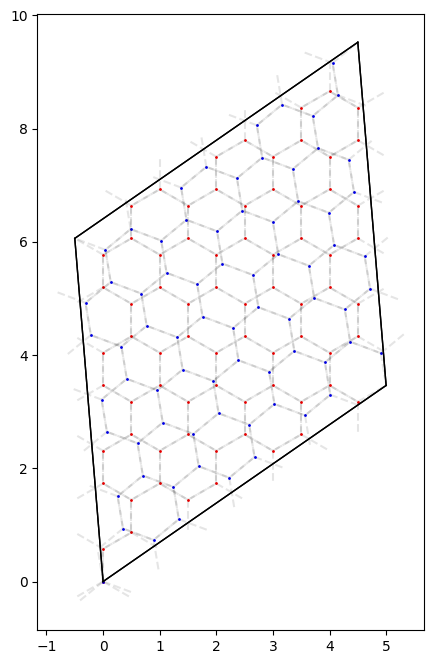

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from moirepy import BilayerMoireLattice, HexagonalLayer

# Define a commensurate TBG lattice
lattice = BilayerMoireLattice(
    latticetype=HexagonalLayer,
    # Config for a ~9.43 degree twist
    # Find these via our tool: https://jabed-umar.github.io/MoirePy/theory/avc/
    ll1=3, ll2=4, ul1=4, ul2=3,
    n1=1, n2=1,    # Number of moiré unit cells
    pbc=True,      # Periodic Boundary Conditions, set False for OBC
)

# Visualize the structure
plt.figure(figsize=(8, 8))
lattice.plot_lattice()

the values `ll1`, `ll2`, `ul1`, `ul2` are the moire lattice indices that define the twist angle and the moire unit cell. You can find these values for any twist angle using our tool: [Angle Value Calculator](https://jabed-umar.github.io/MoirePy/theory/avc/)

## 3. Generate the Hamiltonian

MoirePy separates **geometry** (KDTree-based neighbor search) from **physics** (hopping values). You can pass constants or custom functions for every term.

### Real-Space Hamiltonian

It is very easy to generate the real-space Hamiltonian using `MoirePy`, but first you need to call the `generate_connections` method to find the neighbors. This is slow ($O(n\log n)$) process but it needs to be done just once for each lattice. After that, you can generate Hamiltonians with different hopping parameters fast in $O(n)$ time.

In [2]:
lattice.generate_connections(inter_layer_radius=1)

Although we ae saying `generate_connections` is slow, it is written in rust and practically it get's done in under 100ms for lattices with >5000 sites and then the generation of the Hamiltonian get's done in under 1ms everytime.

In [3]:
real_hamiltonian = lattice.generate_hamiltonian(
    tll=1.0,      # Lower-layer intra-layer hopping
    tuu=1.0,      # Upper-layer intra-layer hopping
    tul=0.1,      # Inter-layer hopping (Upper -> Lower)
    tlu=0.1,      # Inter-layer hopping (Lower -> Upper)
    tlself=0.0,   # Lower-layer onsite potential
    tuself=0.0,   # Upper-layer onsite potential
)  # returns scipy.sparse.coo_matrix not numpy array, to save memory
# use real_hamiltonian.toarray() to convert to dense numpy array if needed

print(f"Hamiltonian Dimension: {real_hamiltonian.shape}")

Hamiltonian Dimension: (148, 148)


!!! warning
    For a Hermitian system, ensure that your `tlu` function/value is the complex conjugate of `tul`. MoirePy does not enforce this automatically by design.

### k-Space Hamiltonian

Essential for band structure calculations. Switching to momentum space requires no structural changes to your logic.

In [4]:
# Get the Hamiltonian at k = (0, 0) for example
phase = lattice.get_phase(k=(0, 0))  # scipy.sparse.coo_matrix of hamiltonian shape
k_hamiltonian = real_hamiltonian.multiply(phase)  # or `real_hamiltonian * phase`` if both are np.arrays

## 4. Compute Low-Energy States

Because the Hamiltonian is returned as a standard SciPy sparse matrix, it integrates perfectly with the scientific Python ecosystem.

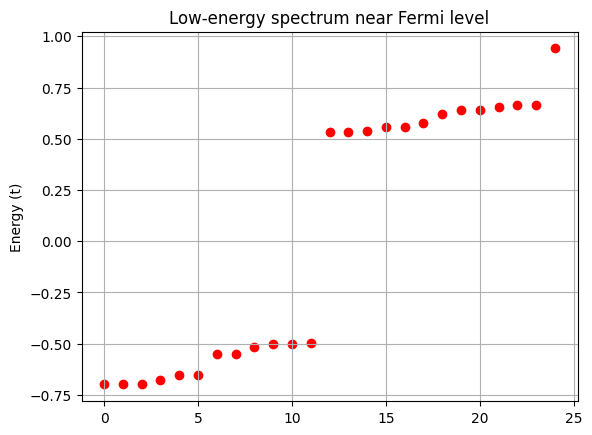

In [5]:
from scipy.sparse.linalg import eigsh

# Find the 25 eigenvalues closest to zero
eigenvalues = eigsh(k_hamiltonian, k=25, sigma=0, return_eigenvectors=False)

plt.scatter(range(len(eigenvalues)), np.sort(eigenvalues), color='red')
plt.ylabel("Energy (t)")
plt.title("Low-energy spectrum near Fermi level")
plt.grid()

## The "Getting Started" Roadmap

Now that you've built your first lattice, dive deeper into the core mechanics:

1. **[K-Space & Band Structures](k_space_hamiltonian.md)**: How to generate k-space Hamiltonians and compute band structures.
2. **[OBC vs PBC](obc_vs_pbc.md)**: How we can simulate both infinite and finite systems using PBC and OBC respectively.
3. **[Defining Custom Layers](prepare_layers.md)**: Move beyond graphene to MoS2, Square lattices, or Kagome.
4. **[Designing Custom Hopping](custom_hoppings.md)**: How to implement distance-dependent (exponential) hopping or strain.
5. **[Tutorials and Replicated Papers](../examples.md)**: See full physical results.